In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, str(Path().resolve().parent))
from scripts.data_loader import (
    load_h5, load_txt, get_file_list,
    offset_and_AHE, normalize,
    coercivity_zero_crossing, exchange_bias, coercive_width,
    sort_serial, fixjump,
)
from scripts.notebook_setup import setup
setup()

PROJECT_ROOT = Path().resolve().parent
D4 = PROJECT_ROOT / 'data' / 'Device4'

[OK] Autoreload enabled
[OK] Project root (installed package): C:\Users\sadit\OneDrive - JGU\Projects\EB in FGT-OFGT_CrPS4
[OK] Matplotlib configured (Okabe-Ito palette, publication style)
Setup complete!


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, str(Path().resolve().parent))
from scripts.data_loader import (
    load_h5, load_txt, get_file_list,
    offset_and_AHE, normalize,
    coercivity_zero_crossing, exchange_bias, coercive_width,
    sort_serial, fixjump,
)
from scripts.notebook_setup import setup
setup()

PROJECT_ROOT = Path().resolve().parent
D2 = PROJECT_ROOT / 'data' / 'Device2'


# â”€â”€ shared: load folder, run analysis, produce per-file diagnostics â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def analyse_folder(folder, skiprows=15, vxy_col='Voltage-2 (V)',
                   channel_xy=2, P=1, fixjump_threshold=None,
                   fixjump_guessindex=None):
    """
    Load all .h5/.txt files, run coercivity analysis, plot per-file diagnostics.
    Returns a dict of arrays keyed by T for each observable.
    """
    T_g, H1_g, H2_g = [], [], []
    Field_g, Vxy_g, Vxy_err_g, Vxx_g, Vxx_err_g = [], [], [], [], []
    Vxy_norm_g, Vahe_g, Vahe_err_g, R_g = [], [], [], []

    for fp in get_file_list(folder):
        if fp.suffix.lower() == '.h5':
            d = load_h5(fp, channel_xy=channel_xy, P=P)
        else:
            d = load_txt(fp, skiprows=skiprows, vxy_col=vxy_col, trim='head')
        F = d['Field'];  Sig = d['Vxy'].copy();  ref = d['Vxx']
        Serr = d['Vxy_err'];  Rerr = d['Vxx_err'];  T = d['T']

        if fp.name.endswith('fix.txt') and fixjump_threshold is not None:
            Sig = fixjump(Sig, fixjump_threshold)
        if fp.suffix.lower() == '.h5' and T == 30 and fixjump_threshold is not None:
            Sig = fixjump(Sig, fixjump_threshold, guessindex=fixjump_guessindex)

        offset, _, Vahe, Vahe_err = offset_and_AHE(Sig)
        Sig_norm = normalize(Sig, offset, Vahe)
        HC_neg, HC_pos = coercivity_zero_crossing(F, Sig_norm)
        HEB = exchange_bias(HC_neg, HC_pos)

        peak = np.max(ref);  idx = np.abs(ref - peak) < 0.5
        R_g.append(np.mean(ref[idx]) if idx.any() else peak)

        T_g.append(T);  H1_g.append(HC_neg);  H2_g.append(HC_pos)
        Field_g.append(F);  Vxy_g.append(Sig);  Vxy_err_g.append(Serr)
        Vxx_g.append(ref);  Vxx_err_g.append(Rerr)
        Vxy_norm_g.append(Sig_norm)
        Vahe_g.append(float(Vahe));  Vahe_err_g.append(float(Vahe_err))


    T_arr   = np.array(T_g)
    H1_arr  = np.array(H1_g);  H2_arr = np.array(H2_g)
    W_arr   = np.abs(H1_arr - H2_arr) / 2
    HEB_arr = (H1_arr + H2_arr) / 2
    sortT   = np.sort(T_arr)
    sortHEB = sort_serial(list(T_arr), list(HEB_arr))
    sortW   = sort_serial(list(T_arr), list(W_arr))

    return dict(
        T_g=T_arr, H1_g=H1_arr, H2_g=H2_arr,
        W=W_arr, HEB=HEB_arr,
        sorted_T=sortT, sorted_HEB=sortHEB, sorted_W=sortW,
        Field_g=Field_g, Vxy_g=Vxy_g, Vxy_err_g=Vxy_err_g,
        Vxx_g=Vxx_g, Vxx_err_g=Vxx_err_g,
        Vxy_norm_g=Vxy_norm_g,
        Vahe_g=np.array(Vahe_g), Vahe_err_g=np.array(Vahe_err_g),
        R_g=np.array(R_g),
    )


def index_of(T_g, T):
    for i, t in enumerate(T_g):
        if t == T:
            return i
    return None


def waterfall_stack(res, groups, dashed_xlim=None):
    """
    Draw waterfall figure for a list of temperature groups.
    groups: list of (T, offset) pairs. Sign flip applied automatically
    if flip_temps set is passed.
    dashed_xlim: (ylo, yhi) for the dashed B=0 vertical line.
    """
    plt.figure(dpi=600)
    labels = []
    for T_val, off, flip in groups:
        i = index_of(res['T_g'], T_val)
        if i is None:
            print(f'[WARNING] T={T_val} K not found');  continue
        sig = (-1 * res['Vxy_norm_g'][i]) if flip else res['Vxy_norm_g'][i]
        plt.errorbar(res['Field_g'][i], sig + off, res['Vxy_err_g'][i], fmt='-', markersize=1,label=f'{T_val} K')
        plt.plot([res['HEB'][i], res['HEB'][i]], [off + 1.1, off + 1.1 - 2.2], '-')
        plt.arrow(0, off, res['HEB'][i], 0, head_width=0.3, head_length=10,
                  length_includes_head=True)
    if dashed_xlim:
        plt.plot([0, 0], list(dashed_xlim), '--', color='k')
    plt.legend( loc='lower right', fontsize=15)
    plt.xlabel('Magnetic Field (mT)', fontsize=20);  plt.ylabel('Vxy (norm.)', fontsize=20)
    plt.xticks([-400, -200, 0, 200, 400], fontsize=15);  plt.yticks([])
    plt.xlim(-450, 450)
    plt.tight_layout();  plt.show()




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[OK] Autoreload enabled
[OK] Project root (installed package): C:\Users\sadit\OneDrive - JGU\Projects\EB in FGT-OFGT_CrPS4
[OK] Matplotlib configured (Okabe-Ito palette, publication style)
Setup complete!


---
## Pristine device PF + FC Comparison
**Device:** FGT-CrPS4-hBN  
**Folder:** `Device4/FC8T_FGT_CPS_hBN/5K_Pre_fields`  

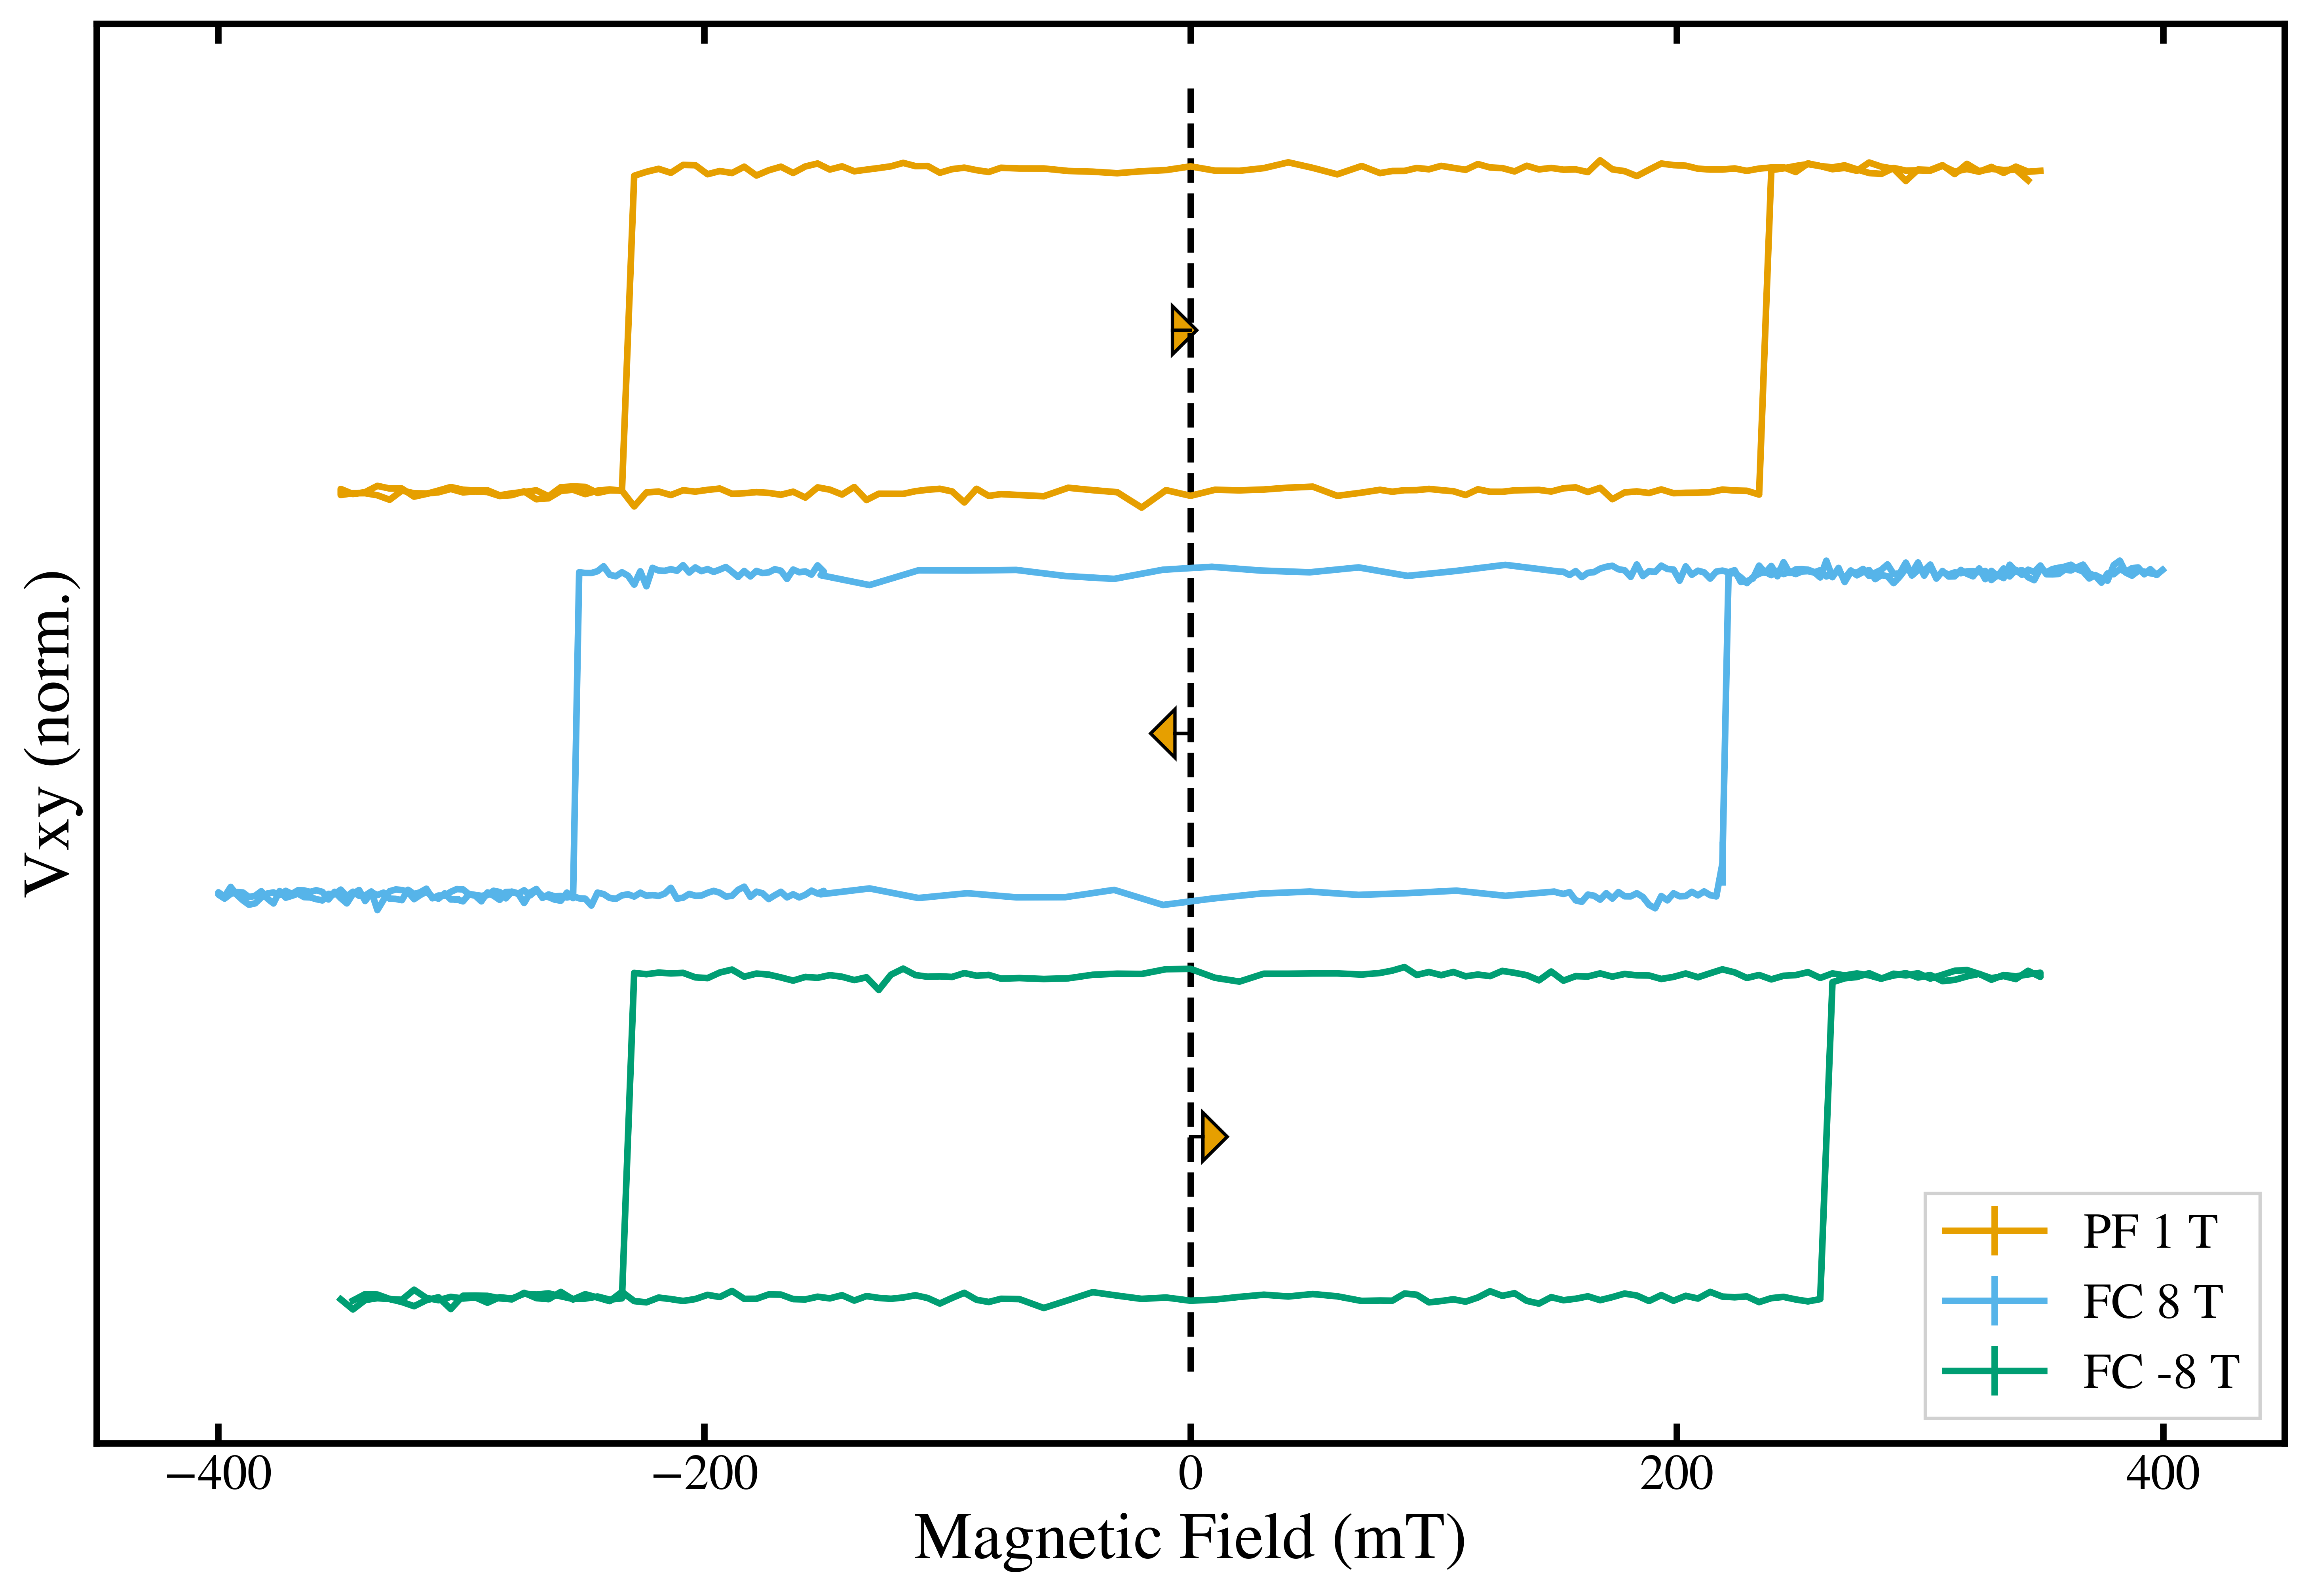

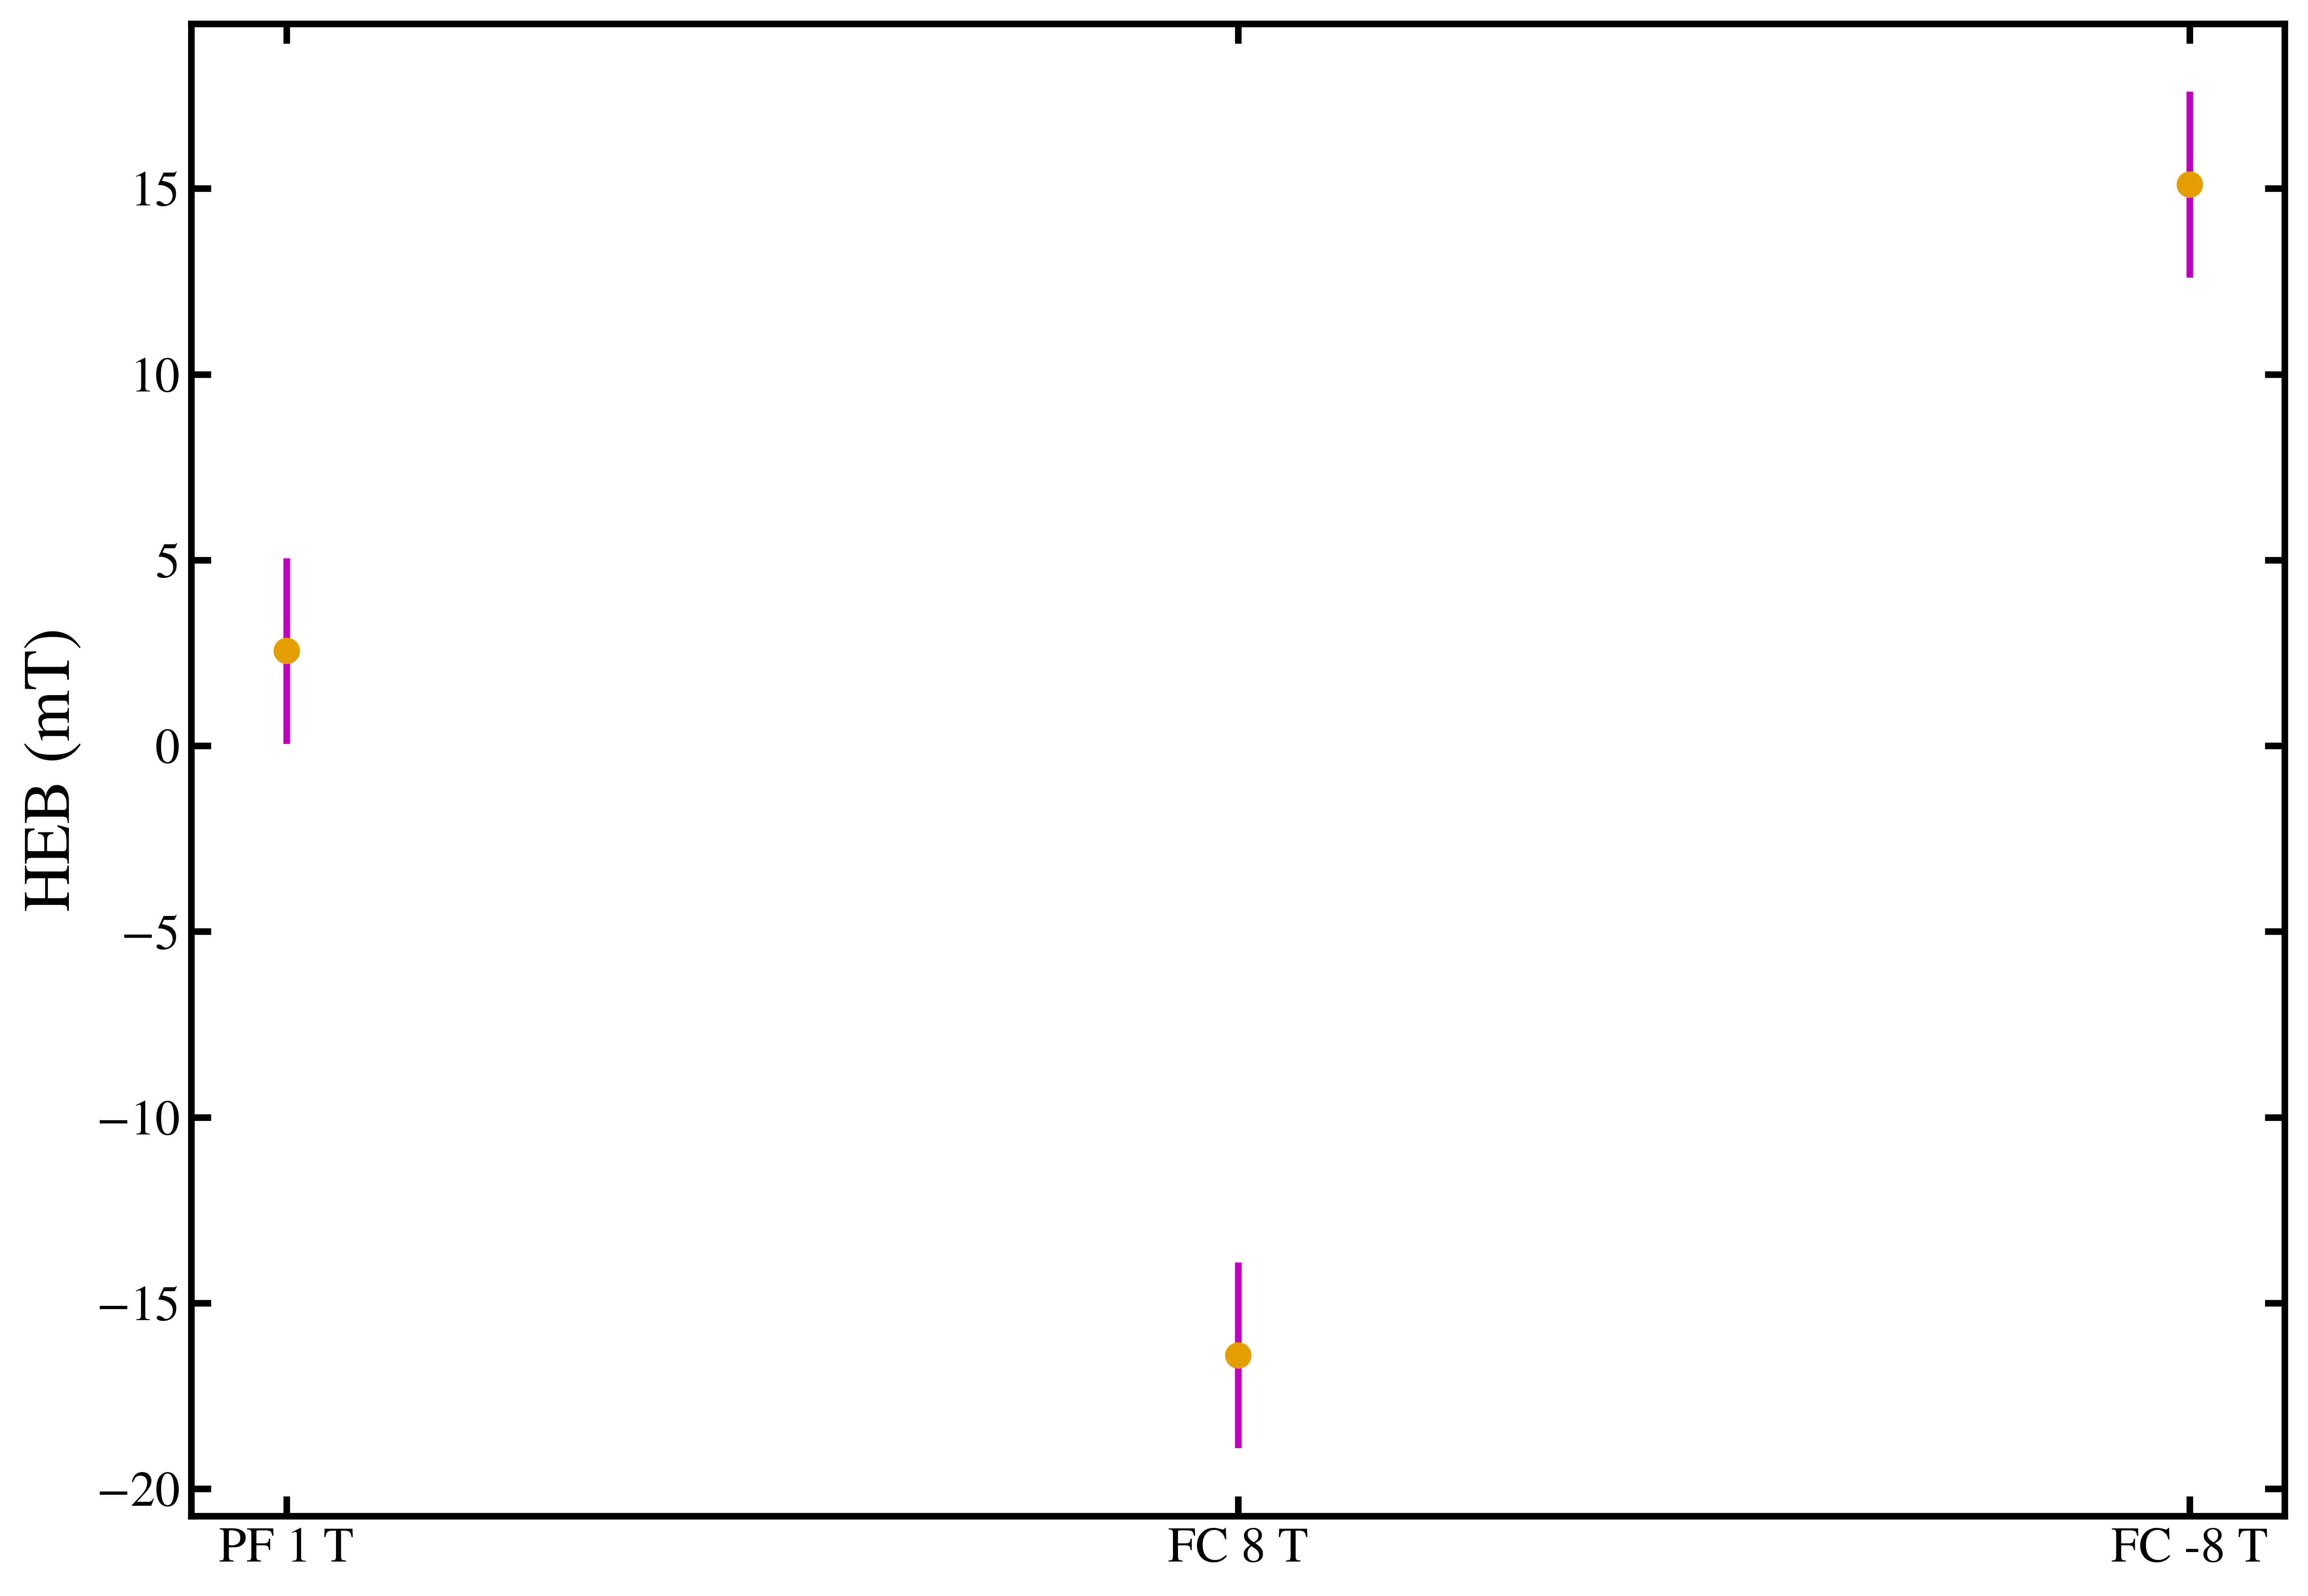

In [4]:

FOLDER_5K_PF = PROJECT_ROOT / 'data' / 'Device4' / 'FC8T_FGT_CPS_hBN' / '5K_Pre_fields'

res_5k = analyse_folder(
    FOLDER_5K_PF, skiprows=16, vxy_col='Voltage-2 (V)',
    fixjump_threshold=0.2, fixjump_guessindex=50
)

# F5: Waterfall PF 1T / FC +8T / FC âˆ’8T
# Uses all 3 loaded files; file loading order determines indices 0,1,2
offsets_5k = [20.5, 18, 15.5]
labels_5k  = ['PF 1 T', 'FC 8 T', 'FC -8 T']

plt.figure(dpi=600)
for i, (off, lbl) in enumerate(zip(offsets_5k, labels_5k)):
    if i < len(res_5k['Field_g']):
        plt.errorbar(res_5k['Field_g'][i], res_5k['Vxy_norm_g'][i] + off,
                     res_5k['Vxy_err_g'][i], fmt='-', markersize=1)
plt.legend(labels_5k, loc='lower right', fontsize=15)
for i, (off, lbl) in enumerate(zip(offsets_5k, labels_5k)):
    if i < len(res_5k['Field_g']):
        plt.arrow(0, off, res_5k['HEB'][i], 0,
                  head_width=0.3, head_length=10, length_includes_head=True)
plt.plot([0, 0], [22, 14], '--', color='k')
plt.xlabel('Magnetic Field (mT)', fontsize=20);  plt.ylabel('Vxy (norm.)', fontsize=20)
plt.xticks([-400, -200, 0, 200, 400], fontsize=15);  plt.yticks([])
plt.xlim(-450, 450)
plt.tight_layout();  plt.show()


plt.figure(dpi=600)
plt.errorbar(labels_5k, res_5k['HEB'], 2.5, fmt='o', ecolor='m')
plt.ylabel('HEB (mT)', fontsize=20)
plt.xticks(fontsize=15);  plt.yticks(fontsize=15)
plt.tight_layout();  plt.show()